<a href="https://colab.research.google.com/github/CaioAntonine/SSD/blob/main/analise_datacenters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignorar alertas de formatação de arquivos antigos
warnings.filterwarnings('ignore')

# 1. Carregamento dos Dados via URL GitHub
url_cost = 'https://raw.githubusercontent.com/CaioAntonine/SSD/refs/heads/main/Cost_of_living_index.xls'
url_dc = 'https://raw.githubusercontent.com/CaioAntonine/SSD/refs/heads/main/combined_data.csv'

try:
    df_cost = pd.read_excel(url_cost, engine='xlrd')
except:
    try:
        df_cost = pd.read_excel(url_cost, engine='openpyxl')
    except:
        df_cost = pd.read_csv(url_cost, sep=',')

df_dc = pd.read_csv(url_dc)

In [ ]:
# 2. Limpeza e Tratamento
def extrair_cidade(nome_completo):
    return str(nome_completo).split(',')[0].strip()

df_cost['Cidade_Merge'] = df_cost['City'].apply(extrair_cidade)

# 3. Agregação de Risco, Diversidade de Provedores e Contexto Geográfico
# Qtd de Data Centers = proxy de maturidade/tempo de mercado
# Qtd de Empresas = proxy de diversificação de fornecedores (menor risco de dependência)
dc_counts = df_dc.groupby('City').size().reset_index(name='Qtd_DataCenters')
dc_empresas = df_dc.groupby('City')['Company'].nunique().reset_index(name='Qtd_Empresas')
dc_continente = df_dc.groupby('City')['Continent'].first().reset_index()

dc_info = dc_counts.merge(dc_empresas, on='City').merge(dc_continente, on='City')

# 4. Cruzamento das Bases
merged = pd.merge(df_cost, dc_info, left_on='Cidade_Merge', right_on='City', how='inner')

analysis_df = merged[[
    'City_x', 'Cost of Living Index', 'Rent Index', 'Groceries Index',
    'Restaurant Price Index', 'Local Purchasing Power Index',
    'Qtd_DataCenters', 'Qtd_Empresas', 'Continent', 'Cidade_Merge'
]].copy()

analysis_df = analysis_df.rename(columns={
    'City_x': 'Localizacao',
    'Cost of Living Index': 'Indice_Custo_Vida',
    'Local Purchasing Power Index': 'Poder_Compra',
    'Restaurant Price Index': 'Indice_Restaurante',
    'Groceries Index': 'Indice_Mercado'
})

In [ ]:
# 5. Seleção do MVP (Top 5)
top_candidates = analysis_df[analysis_df['Qtd_DataCenters'] >= 2].sort_values('Indice_Custo_Vida').head(5)
print("=== TOP 5 CIDADES PARA IMPLEMENTAÇÃO (MVP) ===")
print(top_candidates[['Localizacao', 'Indice_Custo_Vida', 'Qtd_DataCenters', 'Qtd_Empresas']].to_string(index=False))

=== TOP 5 CIDADES PARA IMPLEMENTAÇÃO (MVP) ===
       Localizacao  Indice_Custo_Vida  Qtd_DataCenters  Qtd_Empresas
  Hyderabad, India              23.59                2             2
     Mumbai, India              29.03                4             4
 Queretaro, Mexico              31.01                2             2
Jakarta, Indonesia              41.60                3             3
    Warsaw, Poland              42.32                2             2


## Visualizações Indicativas

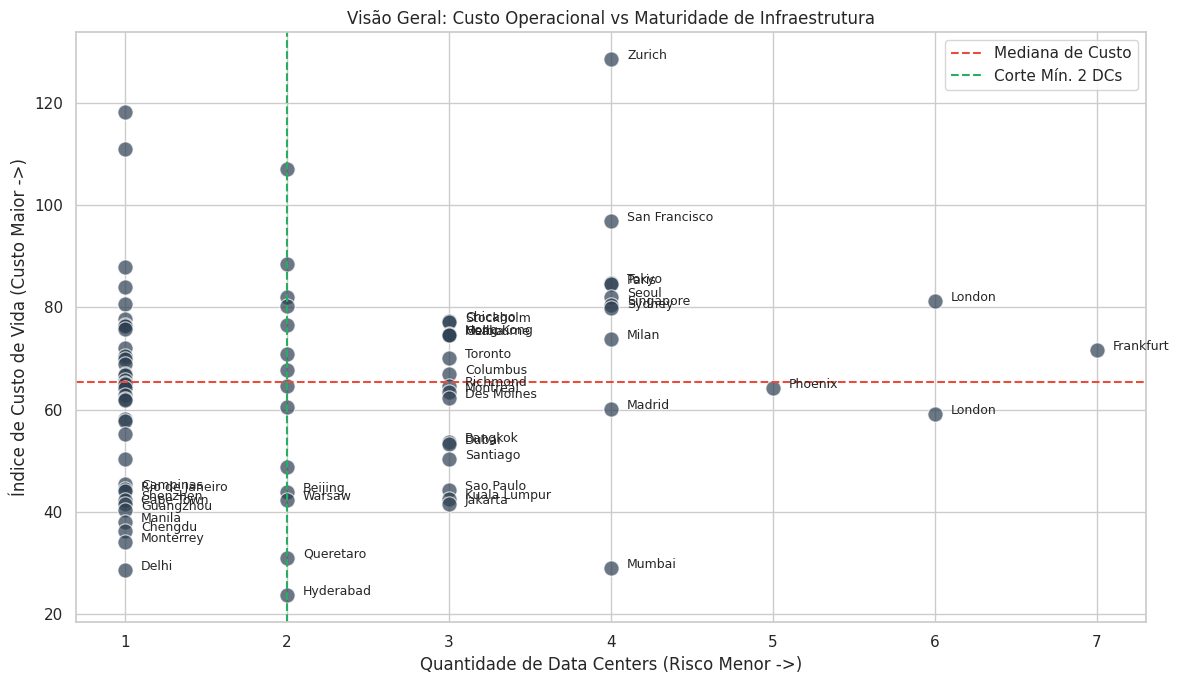

In [ ]:
sns.set_theme(style="whitegrid")

# Gráfico 1: Dispersão (Custo vs Maturidade)
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=analysis_df, x='Qtd_DataCenters', y='Indice_Custo_Vida',
    alpha=0.7, s=120, color='#2C3E50'
)
for i in range(len(analysis_df)):
    if analysis_df.iloc[i]['Qtd_DataCenters'] >= 3 or analysis_df.iloc[i]['Indice_Custo_Vida'] < 45:
        plt.text(
            analysis_df.iloc[i]['Qtd_DataCenters'] + 0.1,
            analysis_df.iloc[i]['Indice_Custo_Vida'],
            analysis_df.iloc[i]['Cidade_Merge'], fontsize=9
        )
plt.title('Visão Geral: Custo Operacional vs Maturidade de Infraestrutura')
plt.xlabel('Quantidade de Data Centers (Risco Menor ->)')
plt.ylabel('Índice de Custo de Vida (Custo Maior ->)')
plt.axhline(y=analysis_df['Indice_Custo_Vida'].median(), color='#E74C3C', linestyle='--', label='Mediana de Custo')
plt.axvline(x=2, color='#27AE60', linestyle='--', label='Corte Mín. 2 DCs')
plt.legend()
plt.tight_layout()
plt.show()

Gráfico de dispersão cruzando o Custo de Vida com a Quantidade de Data Centers. O foco estratégico está no quadrante isolado pela linha verde (corte de viabilidade de risco, com no mínimo 2 data centers) e abaixo da linha vermelha (mediana de custos operacionais).

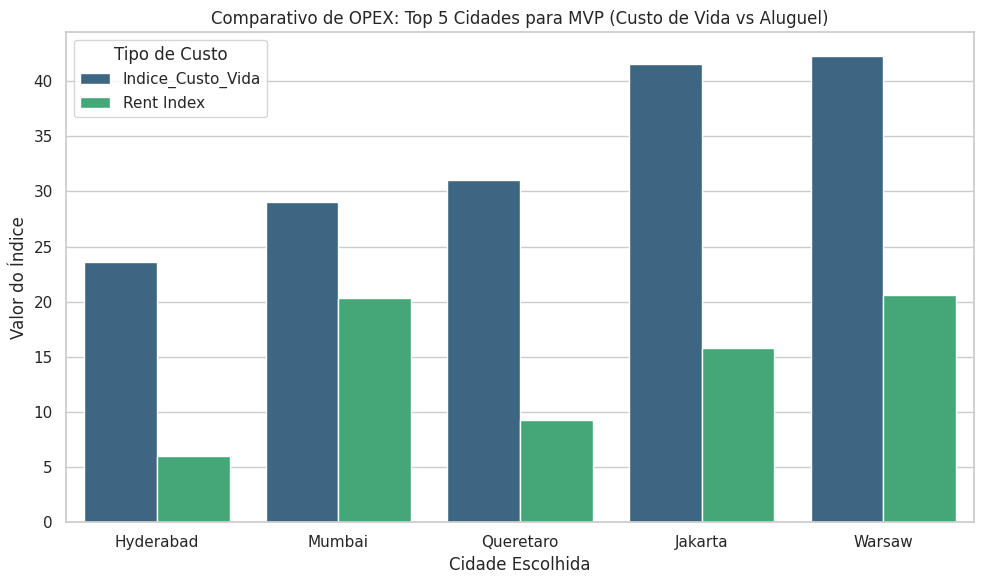

In [ ]:
# Gráfico 2: Detalhamento de Custos (Top 5)
plt.figure(figsize=(10, 6))
top_melted = top_candidates.melt(
    id_vars='Cidade_Merge',
    value_vars=['Indice_Custo_Vida', 'Rent Index'],
    var_name='Indicador', value_name='Valor'
)
sns.barplot(data=top_melted, x='Cidade_Merge', y='Valor', hue='Indicador', palette='viridis')
plt.title('Comparativo de OPEX: Top 5 Cidades para MVP (Custo de Vida vs Aluguel)')
plt.xlabel('Cidade Escolhida')
plt.ylabel('Valor do Índice')
plt.legend(title='Tipo de Custo')
plt.tight_layout()
plt.show()

Comparativo de OPEX (Top 5): Gráfico de barras detalhando as despesas nas cidades finalistas. A justaposição do Índice de Custo de Vida (azul) com o Índice de Aluguel (verde) evidencia locais como Hyderabad e Queretaro, que oferecem custos imobiliários extremamente competitivos para locação ou instalação.

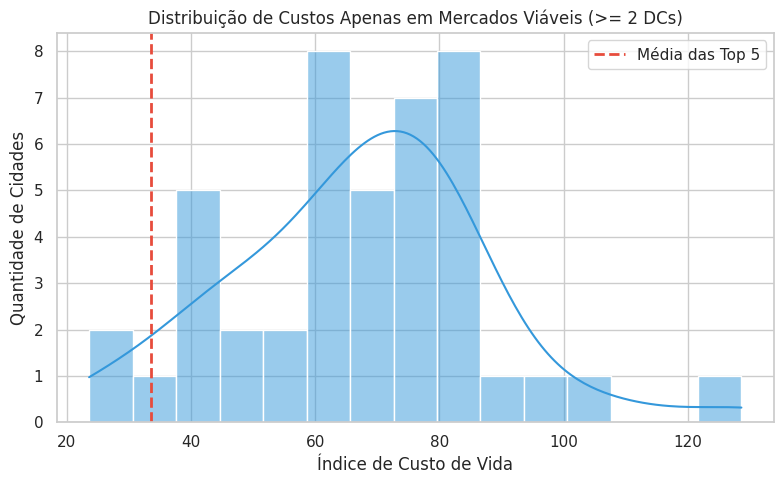

In [ ]:
# Gráfico 3: Distribuição (Contexto de Mercado)
viaveis = analysis_df[analysis_df['Qtd_DataCenters'] >= 2]
plt.figure(figsize=(8, 5))
sns.histplot(viaveis['Indice_Custo_Vida'], bins=15, kde=True, color='#3498DB')
plt.axvline(x=top_candidates['Indice_Custo_Vida'].mean(), color='#E74C3C', linestyle='--', linewidth=2, label='Média das Top 5')
plt.title('Distribuição de Custos Apenas em Mercados Viáveis (>= 2 DCs)')
plt.xlabel('Índice de Custo de Vida')
plt.ylabel('Quantidade de Cidades')
plt.legend()
plt.tight_layout()
plt.show()

Distribuição de Custos em Mercados Viáveis: Histograma focado exclusivamente nas cidades que passaram no filtro de risco (>= 2 DCs). A linha tracejada vermelha prova matematicamente o valor do MVP: o Top 5 escolhido opera em um patamar de custo drasticamente inferior à grande massa do mercado.


## Novas Análises

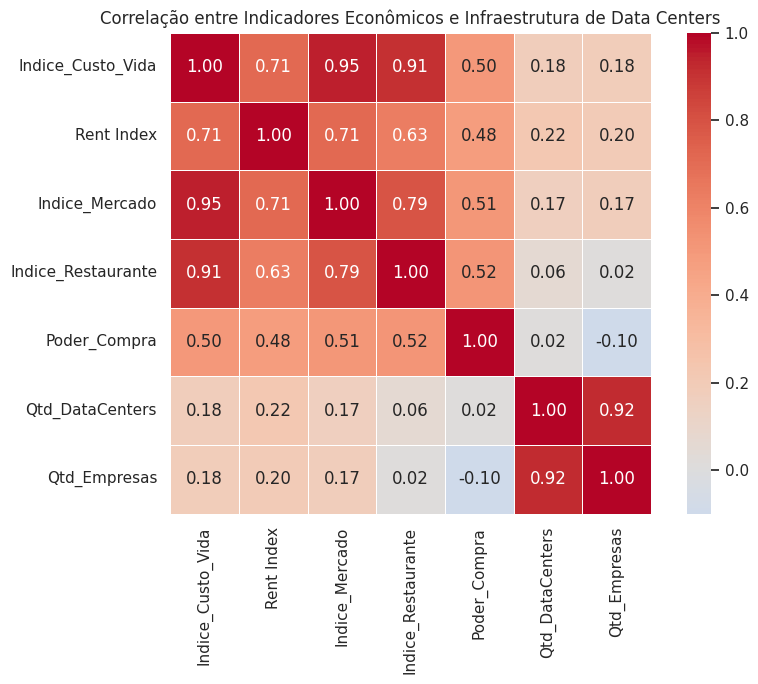

In [ ]:
# Gráfico 4: Mapa de Correlação entre Indicadores Econômicos e de Infraestrutura
cols_corr = [
    'Indice_Custo_Vida', 'Rent Index', 'Indice_Mercado',
    'Indice_Restaurante', 'Poder_Compra', 'Qtd_DataCenters', 'Qtd_Empresas'
]
corr_matrix = analysis_df[cols_corr].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5
)
plt.title('Correlação entre Indicadores Econômicos e Infraestrutura de Data Centers')
plt.tight_layout()
plt.show()

Matriz de Correlação: Mapa de calor que valida a hipótese de risco. A correlação quase perfeita (0.92) entre "Qtd_DataCenters" e "Qtd_Empresas" garante que, ao escolher um mercado com muitos data centers, a empresa inevitavelmente encontra múltiplos fornecedores, evitando dependência técnica.

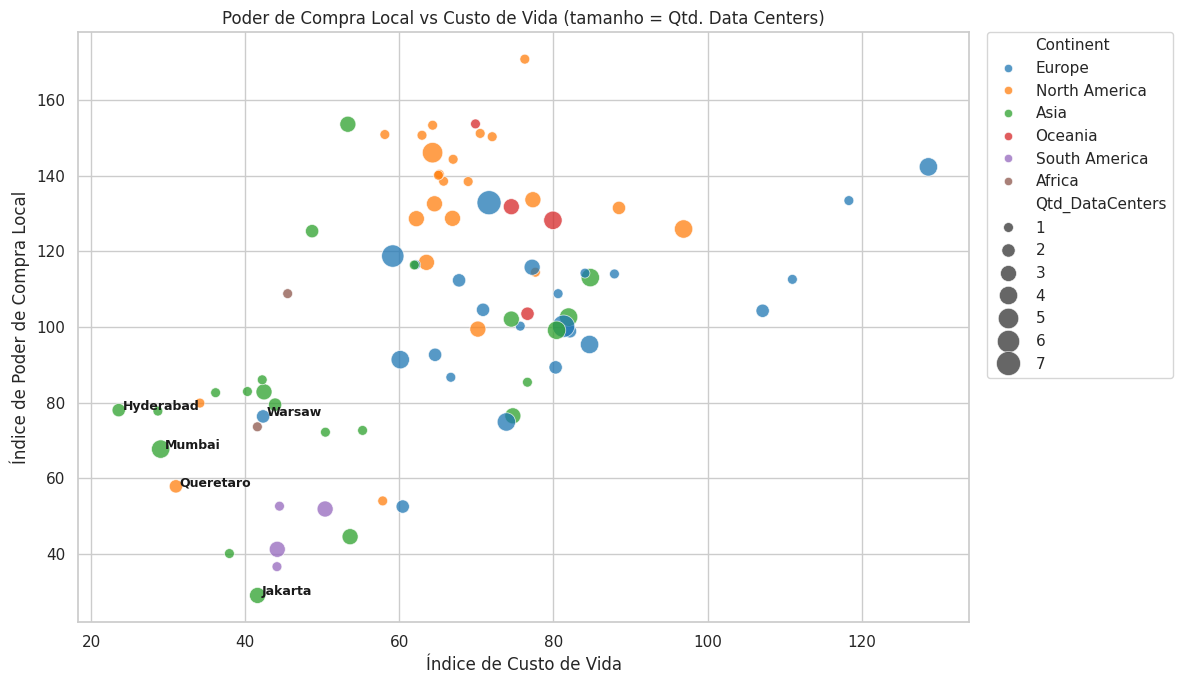

In [ ]:
# Gráfico 5: Poder de Compra Local vs Custo de Vida (Top 5 em destaque)
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=analysis_df, x='Indice_Custo_Vida', y='Poder_Compra',
    size='Qtd_DataCenters', sizes=(50, 300), hue='Continent',
    alpha=0.75, palette='tab10'
)

# Destaca as cidades do Top 5 escolhido para o MVP
for _, row in top_candidates.iterrows():
    plt.text(row['Indice_Custo_Vida'] + 0.5, row['Poder_Compra'], row['Cidade_Merge'],
             fontsize=9, fontweight='bold', color='#1A1A1A')

plt.title('Poder de Compra Local vs Custo de Vida (tamanho = Qtd. Data Centers)')
plt.xlabel('Índice de Custo de Vida')
plt.ylabel('Índice de Poder de Compra Local')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

Poder de Compra vs Custo de Vida: Gráfico de bolhas dimensionado pelo número de data centers e colorido por continente. As cidades do MVP aparecem nomeadas no canto inferior esquerdo, demonstrando o equilíbrio ideal para a folha de pagamento: baixo custo de vida, mas com poder de compra suficiente para atrair talentos locais de TI.

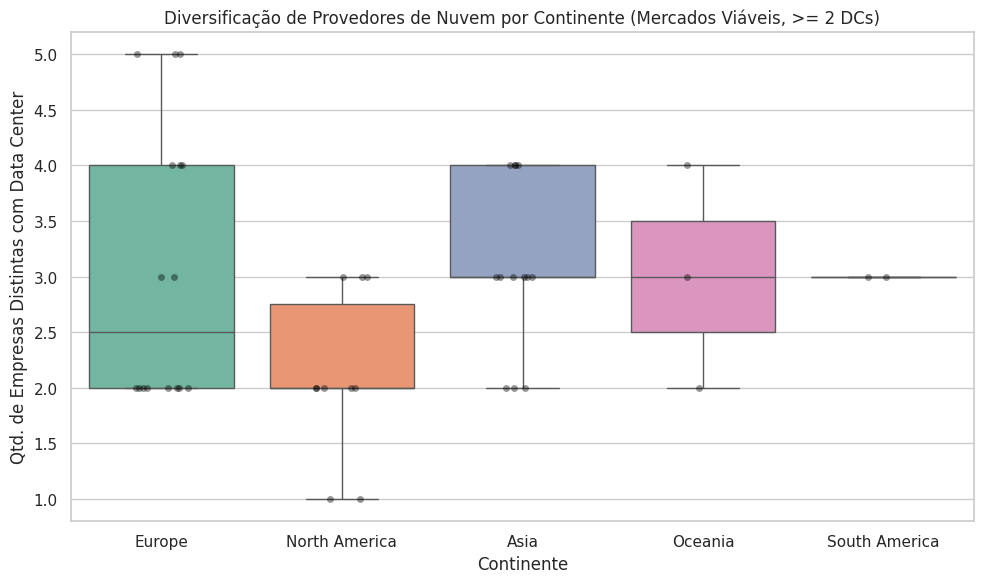

In [ ]:
# Gráfico 6: Diversificação de Provedores por Continente (mercados viáveis)
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=viaveis, x='Continent', y='Qtd_Empresas',
    palette='Set2'
)
sns.stripplot(
    data=viaveis, x='Continent', y='Qtd_Empresas',
    color='black', alpha=0.4, jitter=0.15
)
plt.title('Diversificação de Provedores de Nuvem por Continente (Mercados Viáveis, >= 2 DCs)')
plt.xlabel('Continente')
plt.ylabel('Qtd. de Empresas Distintas com Data Center')
plt.tight_layout()
plt.show()

Diversificação de Provedores por Continente: Boxplot comparando a oferta de empresas de nuvem globalmente. Ásia e Europa lideram com as maiores medianas de diversificação em mercados viáveis, indicando abundância de opções de redundância de rede e fornecimento de energia.

Fase do Projeto,Duração Estimada,Atividades Principais
1. Planejamento e Seleção de Site,3 a 6 meses,"Avaliação de disponibilidade de energia, conectividade de fibra, estabilidade geográfica e ambiente regulatório."
2. Licenciamento e Aprovações,6 a 18 meses,"Obtenção de alvarás de zoneamento, licenças ambientais, direitos de construção e aprovação de concessionárias locais."
3. Design e Engenharia,9 a 12 meses,"Criação de planos arquitetônicos, dimensionamento elétrico, especificação de equipamentos e integração de sistemas de refrigeração."
4. Construção e Implantação,12 a 36 meses,Obras civis tradicionais (12-36 meses) ou instalação de estruturas modulares pré-fabricadas (reduz o tempo estrutural para 3-6 meses).
5. Testes e Comissionamento,2 a 4 meses,"Testes de estresse da infraestrutura, certificação de redundância de sistemas (energia/climatização) antes da operação oficial."